# Import Libs

In [1]:
import pandas as pd
import numpy as np
import time
import sys
import configparser

from tensorflow.keras.layers import Input, Dense, Dropout, Activation, GaussianNoise, BatchNormalization
from tensorflow.keras import losses, activations, optimizers
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
from plotly import graph_objects as go

from shortcut_func import *

sns.set(rc={'figure.figsize':(15, 7)})

In [2]:
path_config = r'C:\Users\oodabasi\Desktop\senarios\otoyol\ver2\conf\cfg.ini'
config = configparser.ConfigParser()
config.read(path_config)

path_data = config['path']['data']
path_base = config['path']['base']
path_main_script = config['path']['main_script']
path_local_script = config['path']['local_script']
file_3g = config['csv']['3g_raw']
sample_cell_list_3g = config['sample']['3g'].split(',')
path_3g = path_data+file_3g

# Import Dataset

In [3]:
df = pd.read_csv(path_3g)
df['DATETIME'] = pd.to_datetime(df['DATETIME'])
df.sort_values(['CELL', 'DATETIME'], inplace=True)

# Exploring Data

In [4]:
print('Raw DataFrame Shape:', df.shape)
df.head(7)

Raw DataFrame Shape: (11224699, 17)


,DATETIME,VENDOR,YOL,RNC,CELL,CS_NQI,PS_NQI,RAB_DR_CS,RAB_DR_PS,CS_ACCESSIBILITY,PS_ACCESSIBILITY,TRAFLOAD_CS_ERL,TRAFLOAD_CELL_PS_MB,SHO_SR,SHO_ATTEMPT,INTER_SYS_OUT_HAND_SR,AVAIBILITY_3G
3488800,2020-07-20 10:00:00,HUAWEI,ADANA_ANKARA,NADNH04,UAD5031A,100.00,96.51,0.00,0.88,100.00,97.37,6.93,552.50,100.00,5085,100.0,100.0
2080898,2020-07-20 11:00:00,HUAWEI,ADANA_ANKARA,NADNH04,UAD5031A,99.57,96.67,0.43,2.12,100.00,98.76,9.33,643.76,99.95,6231,100.0,100.0
7709215,2020-07-20 12:00:00,HUAWEI,ADANA_ANKARA,NADNH04,UAD5031A,99.19,95.68,0.00,2.01,99.19,97.64,10.72,486.12,99.95,6549,100.0,100.0
7965431,2020-07-20 13:00:00,HUAWEI,ADANA_ANKARA,NADNH04,UAD5031A,98.57,97.08,1.43,1.41,100.00,98.47,8.98,826.19,99.98,6131,100.0,100.0
3238212,2020-07-20 14:00:00,HUAWEI,ADANA_ANKARA,NADNH04,UAD5031A,100.00,96.70,0.00,1.13,100.00,97.80,9.17,696.33,99.98,5430,100.0,100.0
7542404,2020-07-20 15:00:00,HUAWEI,ADANA_ANKARA,NADNH04,UAD5031A,100.00,96.23,0.00,0.77,100.00,96.97,9.01,590.84,99.95,5831,100.0,100.0
10202691,2020-07-20 16:00:00,HUAWEI,ADANA_ANKARA,NADNH04,UAD5031A,99.58,96.88,0.42,1.47,100.00,98.32,9.08,458.43,99.90,5241,100.0,100.0


In [5]:
print('Number of Unique Cell:', df.CELL.nunique())

Number of Unique Cell: 6466


### Cell UAD5292G

In [26]:
cell1 = 'UAD5292G'
data_cell1 = df[df['CELL']==cell1]

In [27]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=data_cell1['DATETIME'], y=data_cell1['CS_NQI'], name='CS_NQI'))
fig.add_trace(go.Scatter(x=data_cell1['DATETIME'], y=data_cell1['RAB_DR_CS'], name='RAB_DR_CS'))
fig.add_trace(go.Scatter(x=data_cell1['DATETIME'], y=data_cell1['CS_ACCESSIBILITY'], name='CS_ACCESSIBILITY'))

fig.add_trace(go.Scatter(x=data_cell1['DATETIME'], y=data_cell1['PS_NQI'], name='PS_NQI'))
fig.add_trace(go.Scatter(x=data_cell1['DATETIME'], y=data_cell1['RAB_DR_PS'], name='RAB_DR_PS'))
fig.add_trace(go.Scatter(x=data_cell1['DATETIME'], y=data_cell1['PS_ACCESSIBILITY'], name='PS_ACCESSIBILITY'))

fig.add_trace(go.Scatter(x=data_cell1['DATETIME'], y=data_cell1['SHO_SR'], name='SHO_SR'))
fig.add_trace(go.Scatter(x=data_cell1['DATETIME'], y=data_cell1['AVAIBILITY_3G'], name='AVAIBILITY_3G'))
fig.add_trace(go.Scatter(x=data_cell1['DATETIME'], y=data_cell1['INTER_SYS_OUT_HAND_SR'], name='INTER_SYS_OUT_HAND_SR'))

fig.update_layout(
    title={'text': f"Cell1: {cell1}", 'y':0.9,'x':0.5})

### Cell 

In [8]:
cell2 = 'UMU0163D'
data_cell2 = df[df['CELL']==cell2]

In [9]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=data_cell2['DATETIME'], y=data_cell2['CS_NQI'], name='CS_NQI'))
fig.add_trace(go.Scatter(x=data_cell2['DATETIME'], y=data_cell2['RAB_DR_CS'], name='RAB_DR_CS'))
fig.add_trace(go.Scatter(x=data_cell2['DATETIME'], y=data_cell2['CS_ACCESSIBILITY'], name='CS_ACCESSIBILITY'))

fig.add_trace(go.Scatter(x=data_cell2['DATETIME'], y=data_cell2['PS_NQI'], name='PS_NQI'))
fig.add_trace(go.Scatter(x=data_cell2['DATETIME'], y=data_cell2['RAB_DR_PS'], name='RAB_DR_PS'))
fig.add_trace(go.Scatter(x=data_cell2['DATETIME'], y=data_cell2['PS_ACCESSIBILITY'], name='PS_ACCESSIBILITY'))

fig.add_trace(go.Scatter(x=data_cell2['DATETIME'], y=data_cell2['SHO_SR'], name='SHO_SR'))
fig.add_trace(go.Scatter(x=data_cell2['DATETIME'], y=data_cell2['AVAIBILITY_3G'], name='AVAIBILITY_3G'))
fig.add_trace(go.Scatter(x=data_cell2['DATETIME'], y=data_cell2['INTER_SYS_OUT_HAND_SR'], name='INTER_SYS_OUT_HAND_SR'))

fig.update_layout(
    title={
        'text': f"Cell2: {cell2}", 'y':0.9,'x':0.5,
    })

# Preprocessing 

In [10]:
columns_to_keep = [
    'DATETIME', 'YOL', 'CELL', 
    'CS_NQI', 'RAB_DR_CS', 'CS_ACCESSIBILITY', 'CS_ACCESSIBILITY_DIFF',  # Call Service 
    'PS_NQI', 'RAB_DR_PS', 'PS_ACCESSIBILITY', 'PS_ACCESSIBILITY_DIFF',  # Package Service
    'AVAIBILITY_3G', 'AVAIBILITY_3G_DIFF', 'SHO_SR', 'SHO_SR_DIFF',      # Other Common Cell Metrics
    'INTER_SYS_OUT_HAND_SR', 'INTER_SYS_OUT_HAND_SR_DIFF',
    ]

In [11]:
df_with_anomaly, df_no_anomaly = remove_anomalies(data=df, zscore_threshold=3,)
df_with_anomaly = df_with_anomaly[columns_to_keep]
df_no_anomaly = df_no_anomaly[columns_to_keep]

Droped cell list of low sample:
 ['UAF0019G' 'UAT0248A' 'UAT0248D' 'UAT0464A' 'WAF00196' 'WAF00197'
 'WAF00198' 'WAI0183A' 'WAI0183D' 'WAI01966' 'WAI01967' 'WAI4097A'
 'WAI50316' 'WAI5112A']


c:\users\oodabasi\appdata\local\programs\python\python37_64\lib\site-packages\workalendar\core.py:735: UserWarning:

Please take note that, due to arbitrary decisions, this Islamic calendar computation may be wrong.



641039 point removed of anomaly 
Last shape: 8585770


In [12]:
cell1 = 'UAD5292G'
data_no_anomaly_cell1 = df_no_anomaly[df_no_anomaly['CELL']==cell1]
data_with_anomaly_cell1 = df_with_anomaly[df_with_anomaly['CELL']==cell1]

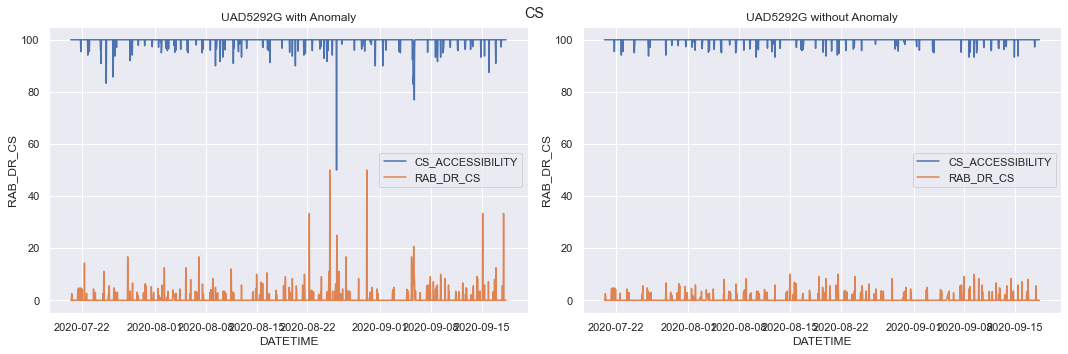

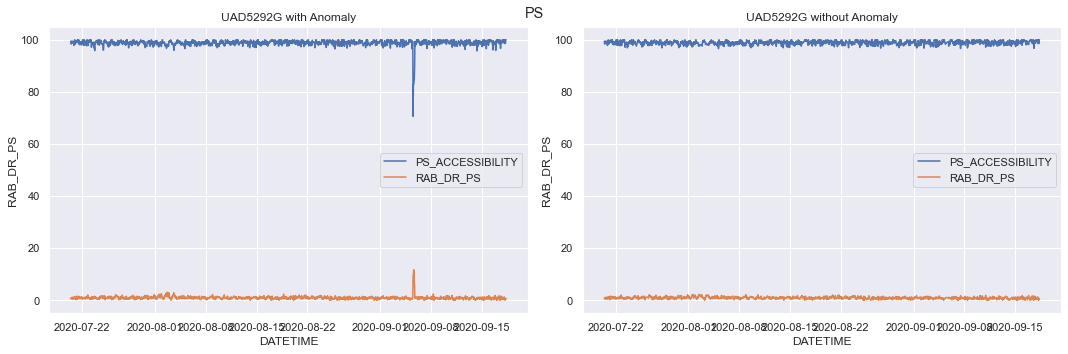

In [13]:
for service_type in ['CS', 'PS']:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

    sns.lineplot(x='DATETIME', y=service_type+'_ACCESSIBILITY', data=data_with_anomaly_cell1,
                 label=service_type+'_ACCESSIBILITY', ax=axes[0])
    sns.lineplot(x='DATETIME', y='RAB_DR_'+service_type, data=data_with_anomaly_cell1,
                 label='RAB_DR_'+service_type, ax=axes[0])
    axes[0].set_title(cell1 + ' with Anomaly')

    sns.lineplot(x='DATETIME', y=service_type+'_ACCESSIBILITY', data=data_no_anomaly_cell1,
                 label=service_type+'_ACCESSIBILITY', ax=axes[1])
    sns.lineplot(x='DATETIME', y='RAB_DR_'+service_type, data=data_no_anomaly_cell1,
                 label='RAB_DR_'+service_type, ax=axes[1])
    axes[1].set_title(cell1+' without Anomaly')
    plt.suptitle(service_type)
    plt.tight_layout()
    plt.show()

## Train Test Validation Split

In [14]:
# Test Split
date_intersect = pd.Timestamp('2020-09-01')
df_train = df_no_anomaly[df_no_anomaly['DATETIME']<date_intersect].copy()

In [15]:
# Validation Split
df_train, df_val, _ , _ = train_test_split(df_train, df_train[['DATETIME']],
                                           test_size=0.085, random_state=23)
print(f'Row sizes\nTrain: {df_train.shape[0]} Validation: {df_val.shape[0]}')

Row sizes
Train: 5611093 Validation: 521250


# Modelling

### Architecture

In [16]:
cols_train = ['RAB_DR_CS', 'CS_ACCESSIBILITY_DIFF',                                # Call Service
              'RAB_DR_PS', 'PS_ACCESSIBILITY_DIFF',                                # Package Service
              'SHO_SR_DIFF', 'INTER_SYS_OUT_HAND_SR_DIFF', 'AVAIBILITY_3G_DIFF',   # Common Metrics
#               'CS_NQI_DIFF',  'PS_NQI_DIFF',
              ]

In [17]:
input_layer = Input((7,))

dense1 = Dense(8)(input_layer)
bn1 = BatchNormalization(trainable=False)(dense1)
gn1 = GaussianNoise(stddev=1.25)(bn1)
act1 = Activation(activation='tanh')(gn1)

dense2 = Dense(8)(act1)
dropout2 = Dropout(0.5)(dense2)
bn2 = BatchNormalization(trainable=False)(dropout2)
act2 = Activation(activation='tanh')(bn2)

dense3 = Dense(2)(act2)
bn3 = BatchNormalization(trainable=False)(dense3)
act3 = Activation(activation='tanh')(bn3)

dense4 = Dense(1)(act3)
bn4 = BatchNormalization(trainable=False)(dense4)
act4 = Activation(activation='tanh')(bn4)

dense5 = Dense(2)(act4)
bn5 = BatchNormalization(trainable=False)(dense5)
act5 = Activation(activation='tanh')(bn5)

dense6 = Dense(8)(act5)
dropout6 = Dropout(0.5)(dense6)
bn6 = BatchNormalization(trainable=False)(dropout6)
act6 = Activation(activation='tanh')(bn6)

dense7 = Dense(8)(act6)
bn7 = BatchNormalization(trainable=False)(dense7)
act7 = Activation(activation='tanh')(bn7)

output_layer = Dense(7, activation='linear')(act7)

model = Model(inputs=[input_layer], outputs=[output_layer])

In [18]:
model.summary()

Model: "functional_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 7)]               0         
_________________________________________________________________
dense (Dense)                (None, 8)                 64        
_________________________________________________________________
batch_normalization (BatchNo (None, 8)                 32        
_________________________________________________________________
gaussian_noise (GaussianNois (None, 8)                 0         
_________________________________________________________________
activation (Activation)      (None, 8)                 0         
_________________________________________________________________
dense_1 (Dense)              (None, 8)                 72        
_________________________________________________________________
dropout (Dropout)            (None, 8)                

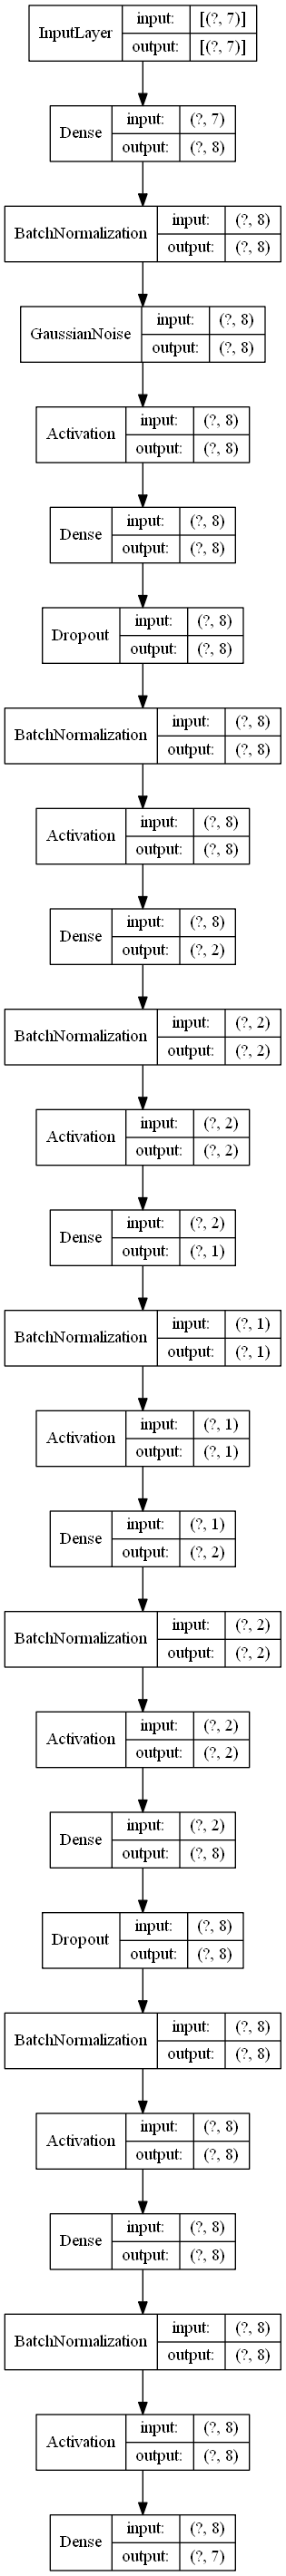

In [19]:
plot_model(model, show_shapes=True, show_layer_names=False, to_file='save/model_architecture.png')

In [20]:
model.compile(loss='mse',
              optimizer=optimizers.RMSprop(learning_rate=0.00075)
             )

### Fitting

In [21]:
# Callbacks
es = EarlyStopping(monitor='val_loss', patience=35)
mc = ModelCheckpoint(filepath='save/best_model.h5', monitor='val_loss', save_best_only=True)

In [22]:
try:
    history = model.fit(x=df_train[cols_train], y=df_train[cols_train],
                        validation_data=(df_val[cols_train], df_val[cols_train]),
                        callbacks=[es, mc],
                        batch_size=128,
                        epochs=200,
                        shuffle=True,
                       )
except KeyboardInterrupt:
    print('\n\nTraining Durduruldu')

model = load_model('save/best_model.h5')

Epoch 1/200
43837/43837 [==============================] - 65s 1ms/step - loss: 5.0949 - val_loss: 1.7663
Epoch 2/200
43837/43837 [==============================] - 64s 1ms/step - loss: 2.8611 - val_loss: 1.7596
Epoch 3/200
43837/43837 [==============================] - 60s 1ms/step - loss: 2.3159 - val_loss: 1.8074
Epoch 4/200
  740/43837 [..............................] - ETA: 53s - loss: 2.0391

Training Durduruldu


In [22]:
model = load_model(r'C:\Users\oodabasi\Desktop\senarios\otoyol\ver2\output\AutoEncoder\AutoEncoder-NoAnomalies\AutoEncoder-3G-NoAnom-BN-KPI-Trial29'+'\\best_model.h5')
df_history = pd.read_csv('save/history.csv')

## Viz

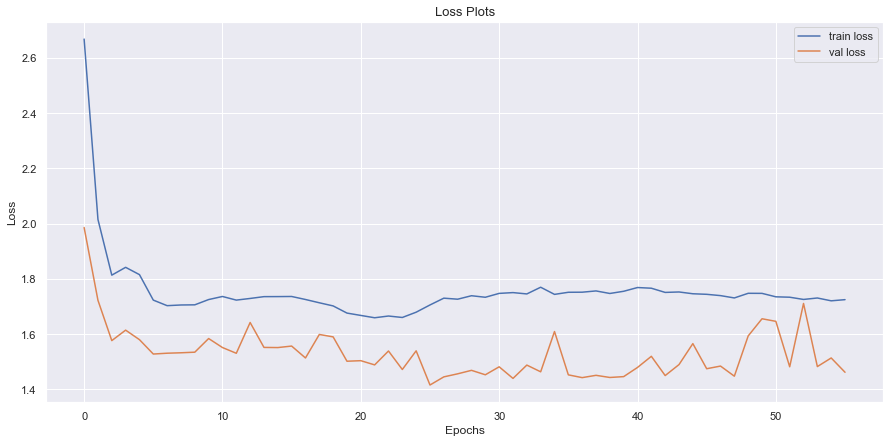

In [23]:
# Loss History Plot
fig = plt.Figure(figsize=(15,5))
plt.plot(df_history['loss'], label='train loss')
plt.plot(df_history['val_loss'], label='val loss')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title('Loss Plots', fontsize=13)
plt.legend()

## Reconstruction Error

In [24]:
calculate_reconstruction_error(df_train, df_val, df_with_anomaly, model)

Train Set:
Reconstruction Error (RMSE): Mean = 0.933 & Std = 3.123
Reconstruction Error (MSE): Mean = 1.518 & Std = 33.942
Reconstruction Error (SE): Mean = 10.623 & Std = 237.596

Validation Set
Reconstruction Error (RMSE): Mean = 0.934 & Std = 3.153
Reconstruction Error (MSE): Mean = 1.545 & Std = 34.358
Reconstruction Error (SE): Mean = 10.816 & Std = 240.505

All DataFrame with Anomalies
Reconstruction Error (RMSE): Mean = 1.473 & Std = 5.966
Reconstruction Error (MSE): Mean = 5.395 & Std = 70.264
Reconstruction Error (SE): Mean = 37.764 & Std = 491.847


## Viz

91825
UAD5292G 2


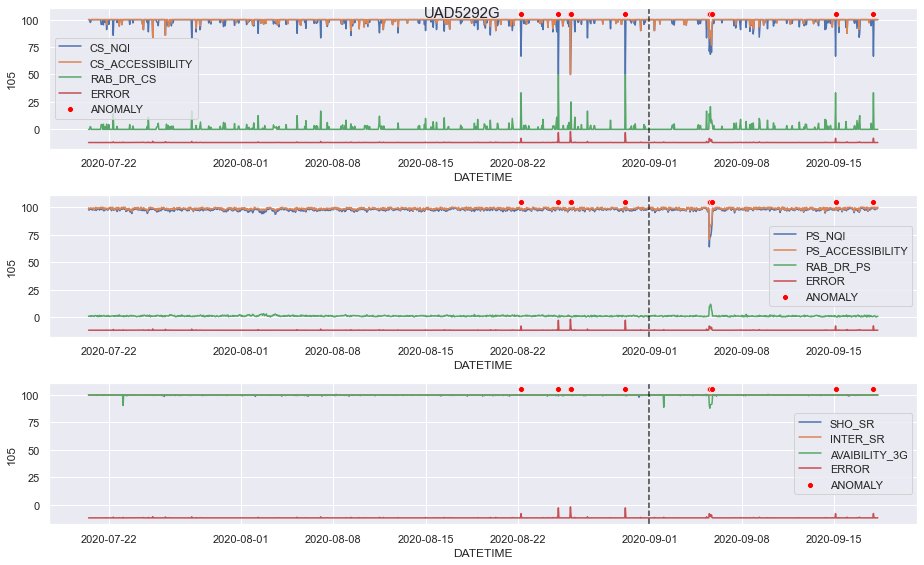

WYA3039A 2


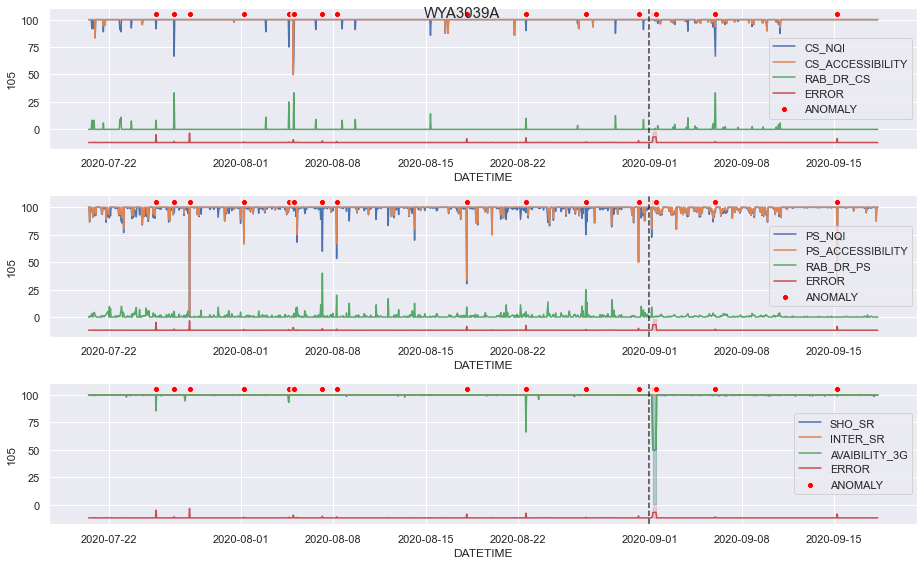

UBA0312G 2


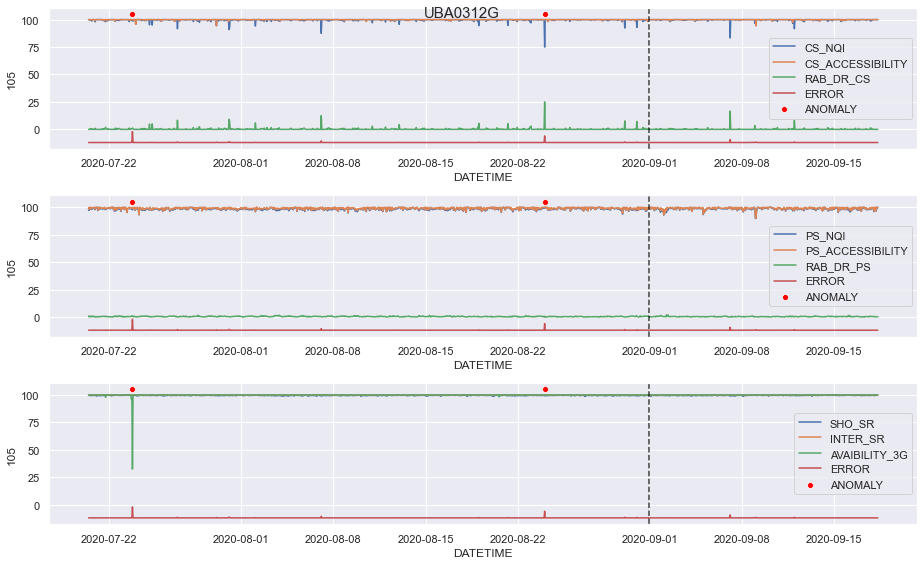

UMU0163D 2


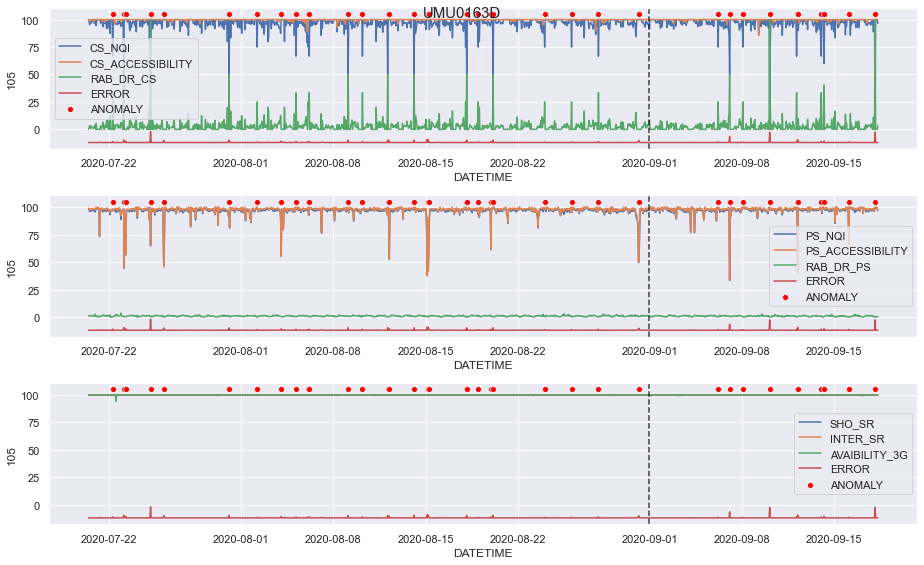

UUS4611G 2


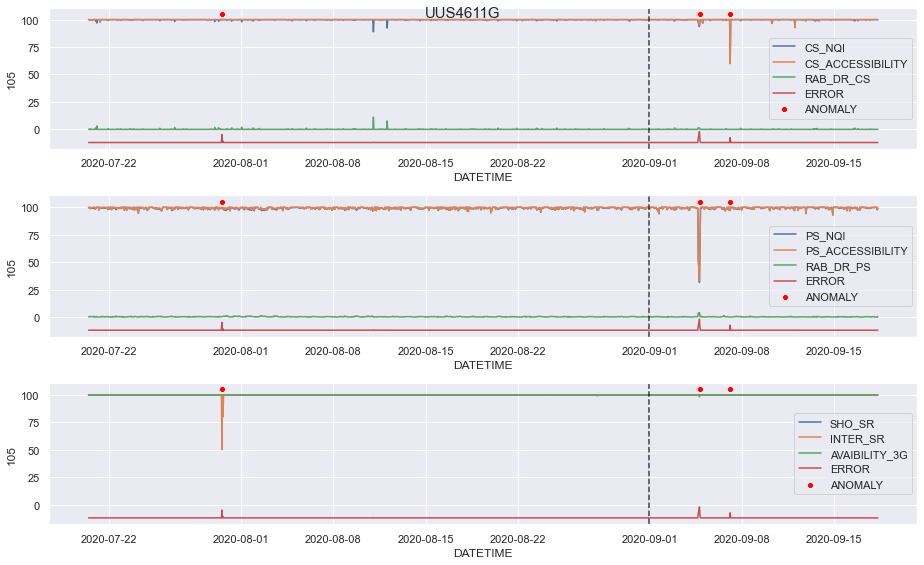

WAF30078 2


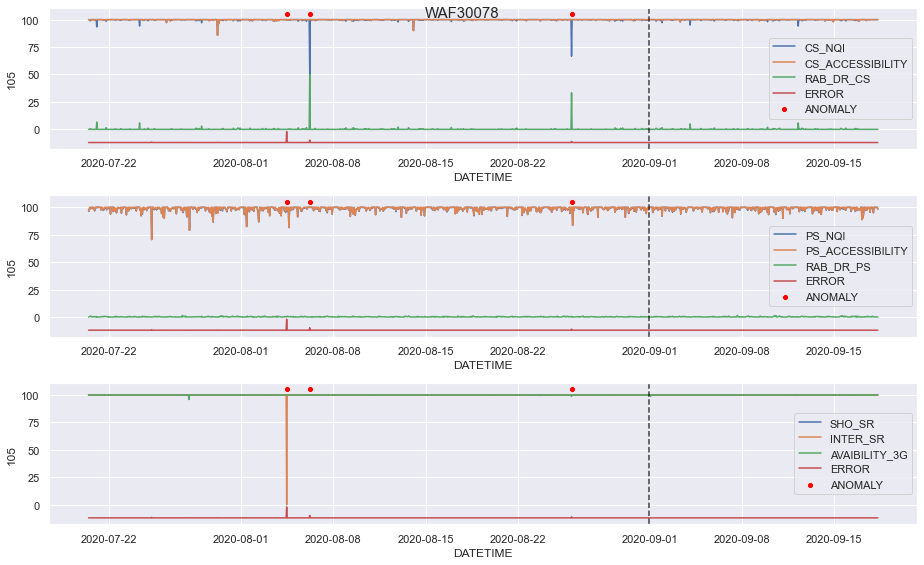

WAN25509 2


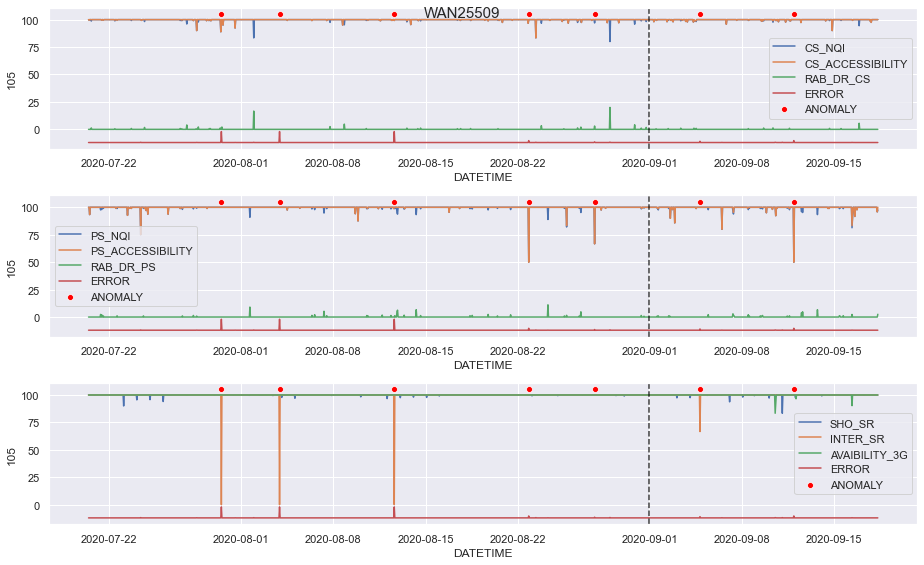

UKU0240A 2


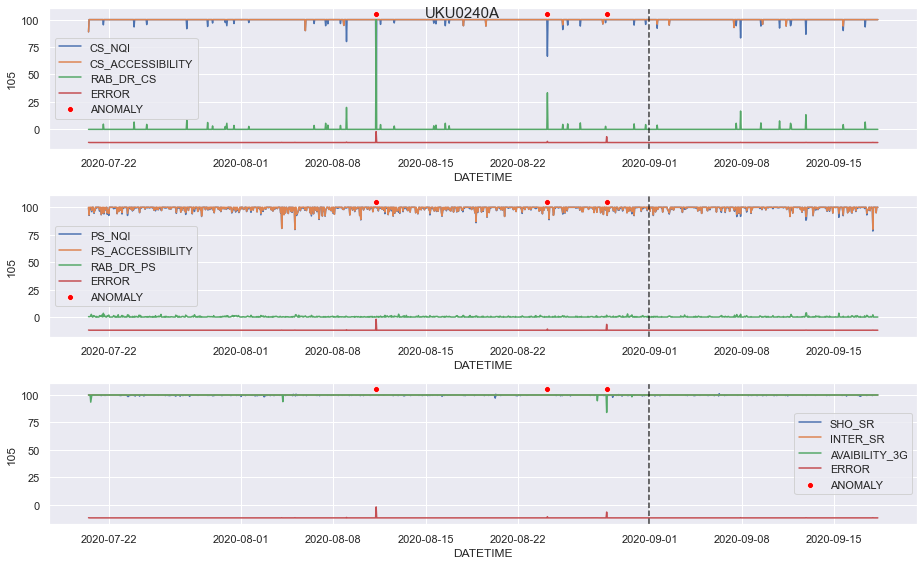

WAT21827 2


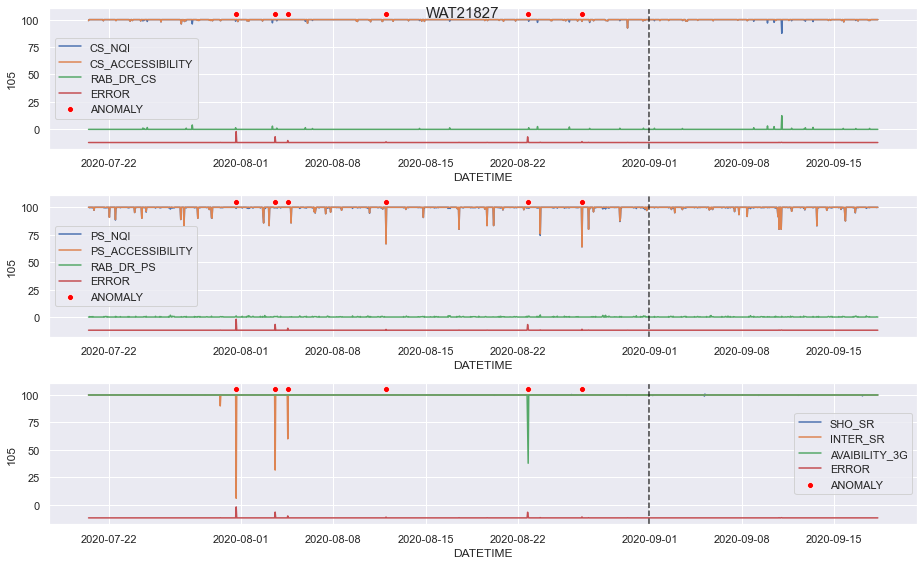

WAD50216 2


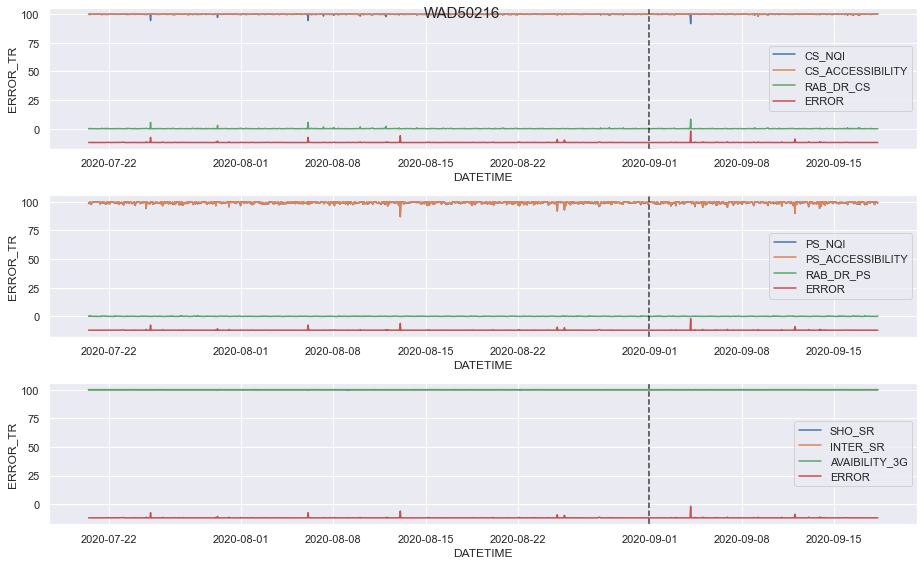

In [26]:
th = 2
df_train = pd.concat([df_train, df_val], axis=0)

df_train['105'] = 105
df_with_anomaly['105'] = 105

df_train['ANOMALY'] = 0
df_train.loc[(df_train['ERROR_Z']>th), 'ANOMALY'] = 1

df_with_anomaly['ANOMALY'] = 0
df_with_anomaly.loc[(df_with_anomaly['ERROR_Z']>th), 'ANOMALY'] = 1

t1 = df_with_anomaly[df_with_anomaly['CELL'].isin(sample_cell_list_3g)].copy()
t1 = t1.sort_values(['CELL', 'DATETIME']) 

print('Total number of anomaly:', df_with_anomaly['ANOMALY'].sum())

for cell in sample_cell_list_3g[:]:
    print(cell, th)
    data = t1[t1['CELL']==cell].copy()
    data['ERROR_TR'] = ((data['ERROR']/data['ERROR'].max())*10)-12
    data_anomaly = data[data['ANOMALY']==1]  # Isolation Forest için

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(13,8))

    sns.lineplot(x='DATETIME', y='CS_NQI', data=data, label='CS_NQI', ax=axes[0])

    sns.lineplot(x=data['DATETIME'], y=data['CS_ACCESSIBILITY'], data=data, 
                 label='CS_ACCESSIBILITY', ax=axes[0])

    sns.lineplot(x=data['DATETIME'], y=data['RAB_DR_CS'], data=data, 
                 label='RAB_DR_CS', ax=axes[0])

    sns.lineplot(x=data['DATETIME'], y=data['ERROR_TR'], 
                 label='ERROR', ax=axes[0])
    sns.scatterplot(x='DATETIME', y='105', data=data_anomaly, label='ANOMALY', color='red', ax=axes[0])

    axes[0].axvline(date_intersect, linestyle='--', color='black', alpha=0.75)

    ###########################################################################################

    sns.lineplot(x='DATETIME', y='PS_NQI', data=data, label='PS_NQI', ax=axes[1])

    sns.lineplot(x=data['DATETIME'], y=data['PS_ACCESSIBILITY'], data=data, 
                 label='PS_ACCESSIBILITY', ax=axes[1])

    sns.lineplot(x=data['DATETIME'], y=data['RAB_DR_PS'], data=data, 
                 label='RAB_DR_PS', ax=axes[1])

    sns.lineplot(x=data['DATETIME'], y=data['ERROR_TR'], 
                 label='ERROR', ax=axes[1])
    sns.scatterplot(x='DATETIME', y='105', data=data_anomaly, label='ANOMALY', color='red', ax=axes[1])

    axes[1].axvline(date_intersect, linestyle='--', color='black', alpha=0.75)

    ###########################################################################################

    sns.lineplot(x=data['DATETIME'], y=data['SHO_SR'], data=data, label='SHO_SR', ax=axes[2])

    sns.lineplot(x=data['DATETIME'], y=data['INTER_SYS_OUT_HAND_SR'], data=data,
                 label='INTER_SR', ax=axes[2])

    sns.lineplot(x=data['DATETIME'], y=data['AVAIBILITY_3G'], data=data,
                 label='AVAIBILITY_3G', ax=axes[2])

    sns.lineplot(x=data['DATETIME'], y=data['ERROR_TR'], 
                 label='ERROR', ax=axes[2])
    sns.scatterplot(x='DATETIME', y='105', data=data_anomaly, label='ANOMALY', color='red', ax=axes[2])

    axes[2].axvline(date_intersect, linestyle='--', color='black', alpha=0.75)

#     axes[0].set_title('CS Features')
#     axes[1].set_title('PS Features')
    fig.suptitle(cell, size=15)
    fig.subplots_adjust(top=1)
    plt.tight_layout()
    plt.show()